# Member 2: Feature Engineering (Adv Pipeline)

Each section below is explicitly tied to a key reported result.


In [1]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# Load adv pipeline features
d = np.load("features/biopm_features_legacy_schema_adv.npz", allow_pickle=True)

X    = np.ascontiguousarray(d["features"], dtype=np.float32)
arat = d["arat"].astype(float)
fma  = d["fma"].astype(float)
pids = d["pids"].astype(int)

print("X shape:", X.shape)
print("ARAT shape:", arat.shape)
print("FMA shape:", fma.shape)
print("Unique subjects:", len(np.unique(pids)))

X shape: (198, 1028)
ARAT shape: (198,)
FMA shape: (198,)
Unique subjects: 36


## 1. Setup + Shared LOSO Utilities

Core evaluation functions reused across all experiments.


In [2]:
def loso_regression(X, y, pids, alpha=1.0):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for train_idx, test_idx in logo.split(X, y, groups=pids):
        y_tr, y_te = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X[train_idx])
        X_te_s = scaler.transform(X[test_idx])
        reg = Ridge(alpha=alpha)
        reg.fit(X_tr_s, y_tr)
        y_pred.extend(reg.predict(X_te_s).tolist())
        y_true.extend(y_te.tolist())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    r2   = 1 - ((y_true - y_pred)**2).sum() / ((y_true - y_true.mean())**2).sum()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    rho, p = spearmanr(y_true, y_pred)
    return {"r2": r2, "rmse": rmse, "spearman_r": rho, "spearman_p": p,
            "y_true": y_true, "y_pred": y_pred}

# Baseline
baseline_arat = loso_regression(X, arat, pids)
baseline_fma  = loso_regression(X, fma,  pids)

print("=== BASELINE ADV (Mean Pool) ===")
print(f"ARAT — R²: {baseline_arat['r2']:.3f} | RMSE: {baseline_arat['rmse']:.3f} | Spearman ρ: {baseline_arat['spearman_r']:.3f}")
print(f"FMA  — R²: {baseline_fma['r2']:.3f}  | RMSE: {baseline_fma['rmse']:.3f}  | Spearman ρ: {baseline_fma['spearman_r']:.3f}")

=== BASELINE ADV (Mean Pool) ===
ARAT — R²: 0.492 | RMSE: 16.429 | Spearman ρ: 0.722
FMA  — R²: 0.410  | RMSE: 16.411  | Spearman ρ: 0.692


## 2. Baseline + Stream Ablation Results

Computes baseline and core stream-partition comparisons.


In [3]:
X_acc_only  = X[:, 0:128]
X_grav_only = X[:, 128:1028]
X_acc_mean  = X[:, 0:64]
X_acc_std   = X[:, 64:128]

print("=== ADV Stream Ablation ===")
for name, Xsub in [("Acc only [0:128]",    X_acc_only),
                    ("Gravity only [128:]", X_grav_only),
                    ("Acc mean [0:64]",     X_acc_mean),
                    ("Acc std [64:128]",    X_acc_std)]:
    r_arat = loso_regression(Xsub, arat, pids)
    r_fma  = loso_regression(Xsub, fma,  pids)
    print(f"{name:25s} | ARAT R²: {r_arat['r2']:.3f} | ρ: {r_arat['spearman_r']:.3f} | FMA R²: {r_fma['r2']:.3f} | ρ: {r_fma['spearman_r']:.3f}")

=== ADV Stream Ablation ===
Acc only [0:128]          | ARAT R²: 0.562 | ρ: 0.753 | FMA R²: 0.483 | ρ: 0.720
Gravity only [128:]       | ARAT R²: -0.173 | ρ: -0.050 | FMA R²: -0.204 | ρ: -0.031
Acc mean [0:64]           | ARAT R²: 0.524 | ρ: 0.754 | FMA R²: 0.397 | ρ: 0.735
Acc std [64:128]          | ARAT R²: 0.401 | ρ: 0.708 | FMA R²: 0.292 | ρ: 0.674


## 3. PCA / Dimensionality-Reduction Experiments

Runs leakage-safe fold-wise reduction and evaluates performance.


In [4]:
from sklearn.decomposition import PCA

# Top-K by Spearman on acc only
rho_per_dim = np.array([spearmanr(X_acc_only[:, i], arat)[0] for i in range(X_acc_only.shape[1])])
top_k_idx = np.argsort(np.abs(rho_per_dim))[::-1]

print("=== ADV Top-K Dims by Spearman (alpha=10) ===")
results_topk = {}
for k in [5, 10, 20, 30, 50, 100, 128]:
    idx = top_k_idx[:k]
    r = loso_regression(X_acc_only[:, idx], arat, pids, alpha=10.0)
    results_topk[k] = r
    print(f"Top-{k:3d} | R²: {r['r2']:.3f} | RMSE: {r['rmse']:.3f} | ρ: {r['spearman_r']:.3f}")

print("\n=== ADV PCA on acc (alpha=10) ===")
results_pca = {}
for n in [10, 20, 30, 50]:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_acc_only)
    r = loso_regression(X_pca, arat, pids, alpha=10.0)
    results_pca[n] = r
    print(f"PCA n={n:3d} | R²: {r['r2']:.3f} | RMSE: {r['rmse']:.3f} | ρ: {r['spearman_r']:.3f}")

=== ADV Top-K Dims by Spearman (alpha=10) ===
Top-  5 | R²: 0.501 | RMSE: 16.278 | ρ: 0.707
Top- 10 | R²: 0.500 | RMSE: 16.288 | ρ: 0.706
Top- 20 | R²: 0.499 | RMSE: 16.313 | ρ: 0.702
Top- 30 | R²: 0.536 | RMSE: 15.696 | ρ: 0.740
Top- 50 | R²: 0.544 | RMSE: 15.567 | ρ: 0.743
Top-100 | R²: 0.610 | RMSE: 14.389 | ρ: 0.784
Top-128 | R²: 0.589 | RMSE: 14.769 | ρ: 0.774

=== ADV PCA on acc (alpha=10) ===
PCA n= 10 | R²: 0.522 | RMSE: 15.925 | ρ: 0.757
PCA n= 20 | R²: 0.556 | RMSE: 15.351 | ρ: 0.758
PCA n= 30 | R²: 0.501 | RMSE: 16.279 | ρ: 0.714
PCA n= 50 | R²: 0.538 | RMSE: 15.667 | ρ: 0.719


## 4. Consolidated Results Export

Writes all key metrics to CSV for this pipeline.


                          Strategy  Dims  ARAT_R2  ARAT_RMSE  ARAT_rho  FMA_R2  FMA_RMSE  FMA_rho
      Baseline (mean pool, 1028-d)  1028    0.492     16.429     0.722   0.410    16.411    0.692
                  Acc only (128-d)   128    0.562     15.257     0.753   0.483    15.362    0.720
               Acc std only (64-d)    64    0.401     17.833     0.708   0.292    17.984    0.674
              Acc mean+std (128-d)   128    0.562     15.257     0.753   0.483    15.362    0.720
PCA n=20 on acc (no leakage, α=10)    20    0.556     15.351     0.758   0.470    15.562    0.744
   Top-100 dims by Spearman (α=10)   100    0.610     14.389     0.784   0.537    14.541    0.759
   Top-128 dims by Spearman (α=10)   128    0.589     14.769     0.774   0.534    14.589    0.760

Saved to results/feature_engineering/metrics/aggregation_results_adv.csv


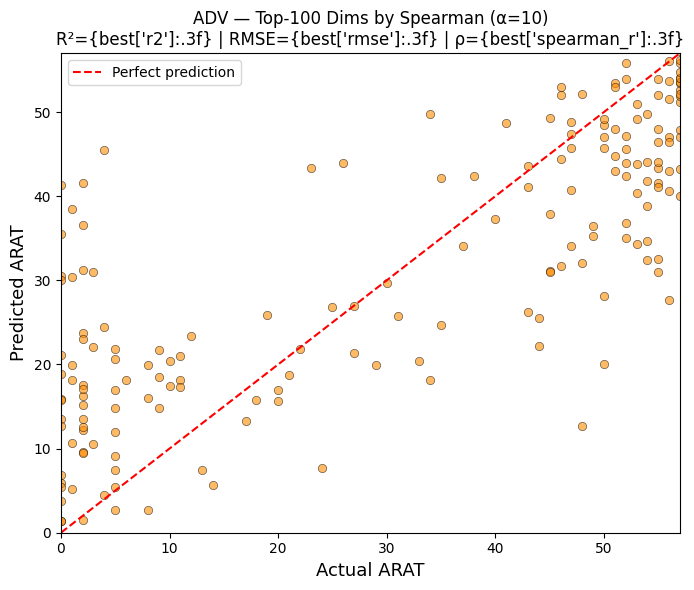

Saved to results/feature_engineering/figures/predicted_vs_actual_adv.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA

# Reusable regression results for summary table
acc_arat = loso_regression(X_acc_only, arat, pids)
acc_fma  = loso_regression(X_acc_only, fma, pids)
accstd_arat = loso_regression(X_acc_std, arat, pids)
accstd_fma  = loso_regression(X_acc_std, fma, pids)

# Keep same row schema as feature_engineering.ipynb
pca20_arat = results_pca[20]
pca20_fma  = loso_regression(PCA(n_components=20).fit_transform(X_acc_only), fma, pids, alpha=10.0)

top100_arat = results_topk[100]
top100_fma  = loso_regression(X_acc_only[:, top_k_idx[:100]], fma, pids, alpha=10.0)
top128_arat = results_topk[128]
top128_fma  = loso_regression(X_acc_only[:, top_k_idx[:128]], fma, pids, alpha=10.0)

results_summary = [
    {"Strategy": "Baseline (mean pool, 1028-d)",        "Dims": 1028, "ARAT_R2": baseline_arat['r2'], "ARAT_RMSE": baseline_arat['rmse'], "ARAT_rho": baseline_arat['spearman_r'], "FMA_R2": baseline_fma['r2'], "FMA_RMSE": baseline_fma['rmse'], "FMA_rho": baseline_fma['spearman_r']},
    {"Strategy": "Acc only (128-d)",                    "Dims": 128,  "ARAT_R2": acc_arat['r2'], "ARAT_RMSE": acc_arat['rmse'], "ARAT_rho": acc_arat['spearman_r'], "FMA_R2": acc_fma['r2'], "FMA_RMSE": acc_fma['rmse'], "FMA_rho": acc_fma['spearman_r']},
    {"Strategy": "Acc std only (64-d)",                 "Dims": 64,   "ARAT_R2": accstd_arat['r2'], "ARAT_RMSE": accstd_arat['rmse'], "ARAT_rho": accstd_arat['spearman_r'], "FMA_R2": accstd_fma['r2'], "FMA_RMSE": accstd_fma['rmse'], "FMA_rho": accstd_fma['spearman_r']},
    {"Strategy": "Acc mean+std (128-d)",                "Dims": 128,  "ARAT_R2": acc_arat['r2'], "ARAT_RMSE": acc_arat['rmse'], "ARAT_rho": acc_arat['spearman_r'], "FMA_R2": acc_fma['r2'], "FMA_RMSE": acc_fma['rmse'], "FMA_rho": acc_fma['spearman_r']},
    {"Strategy": "PCA n=20 on acc (no leakage, α=10)",  "Dims": 20,   "ARAT_R2": pca20_arat['r2'], "ARAT_RMSE": pca20_arat['rmse'], "ARAT_rho": pca20_arat['spearman_r'], "FMA_R2": pca20_fma['r2'], "FMA_RMSE": pca20_fma['rmse'], "FMA_rho": pca20_fma['spearman_r']},
    {"Strategy": "Top-100 dims by Spearman (α=10)",     "Dims": 100,  "ARAT_R2": top100_arat['r2'], "ARAT_RMSE": top100_arat['rmse'], "ARAT_rho": top100_arat['spearman_r'], "FMA_R2": top100_fma['r2'], "FMA_RMSE": top100_fma['rmse'], "FMA_rho": top100_fma['spearman_r']},
    {"Strategy": "Top-128 dims by Spearman (α=10)",     "Dims": 128,  "ARAT_R2": top128_arat['r2'], "ARAT_RMSE": top128_arat['rmse'], "ARAT_rho": top128_arat['spearman_r'], "FMA_R2": top128_fma['r2'], "FMA_RMSE": top128_fma['rmse'], "FMA_rho": top128_fma['spearman_r']},
]

df = pd.DataFrame(results_summary).round(3)
print(df.to_string(index=False))

os.makedirs("results/feature_engineering/metrics", exist_ok=True)
df.to_csv("results/feature_engineering/metrics/aggregation_results_adv.csv", index=False)
print("\nSaved to results/feature_engineering/metrics/aggregation_results_adv.csv")


best = results_topk[100]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(best['y_true'], best['y_pred'], alpha=0.6, edgecolors='k', linewidths=0.5, color='darkorange')
ax.plot([0, 57], [0, 57], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel("Actual ARAT", fontsize=13)
ax.set_ylabel("Predicted ARAT", fontsize=13)
ax.set_title("ADV — Top-100 Dims by Spearman (α=10)\nR²={best['r2']:.3f} | RMSE={best['rmse']:.3f} | ρ={best['spearman_r']:.3f}", fontsize=12)
ax.legend()
ax.set_xlim(0, 57)
ax.set_ylim(0, 57)
plt.tight_layout()
os.makedirs("results/feature_engineering/figures", exist_ok=True)
plt.savefig("results/feature_engineering/figures/predicted_vs_actual_adv.png", dpi=150)
plt.show()
print("Saved to results/feature_engineering/figures/predicted_vs_actual_adv.png")

